# Parte IV: Análisis Exploratorio de Datos (EDA) y Visualización

En esta cuarta parte del proyecto, aplicaremos técnicas avanzadas de análisis exploratorio de datos (EDA) y visualización para comprender mejor el conjunto de datos de ventas de la tienda de retail. Utilizaremos Python, Pandas y Matplotlib para explorar y visualizar los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.

 

## Instrucciones

Continuar desde la Parte III
Asegúrate de tener el repositorio de GitHub clonado localmente y el dataset ya limpiado y preparado desde la Parte III.
Análisis Descriptivo y Visualización
Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.
Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.
Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.
Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.
Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.
Generar un Pull Request en GitHub
Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub y genera un Pull Request (PR) para revisión.

## Carga de Libreas y data

In [2]:
#1.1 cargar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# 1.2- Carga data
df = pd.read_csv('../data/retail_sales_dataset.csv')

# Numero de filas y columnas
print(df.shape)

# información general del data frame
print(df.info())

# muestra las primeras filas del data frame
print(df.head(5))

# muestra las últimas filas del data frame
print(df.tail(5))

# Datos estadísticos del data frame
print(df.describe())


(1000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB
None
   Transaction ID        Date Customer ID  Gender  Age Product Category  Quantity  Price per Unit  \
0               1  2023-11-24     CUST001    Male   34           Beauty         3              50   
1               2  2023-02-27     CUST002  Female   26         Clothing         2             500   
2               3  2023-01-13     CUST003    M

## Limipeza de data

### a) Datos Faltantes (Nulls) y Registros Duplicados

Ejecutamos un escaneo sobre todo el dataframe para cuantificar la presencia de vacíos de información o redundancias que puedan alterar los estadísticos descriptivos.

In [4]:
# Verificación de tipos de datos y estructuras nulas
print("--- Conteo de Valores Nulos por Variable ---")
print(df.describe())
print(df.isnull().sum())

print("\n" + "="*50 + "\n")

# Verificación de filas idénticas o duplicadas
duplicados_totales = df.duplicated().sum()
print(f"Cantidad de registros completamente duplicados detectados: {duplicados_totales}")

--- Conteo de Valores Nulos por Variable ---
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


Cantidad de registros completamente duplicados de

### b) Tratamiento de Variables y Preparación Temporal

Para asegurar la correcta interpretación de los ejes cronológicos en las visualizaciones, transformamos explícitamente la columna de fechas a un objeto especializado `datetime`.

In [5]:
# Conversión estricta de tipos de datos
df['Date'] = pd.to_datetime(df['Date'])

print("--- Verificación del esquema de tipos de datos final ---")
df.dtypes

--- Verificación del esquema de tipos de datos final ---


Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

### c) Análisis Analítico de Outliers (Límites Estadísticos)

Antes de pasar a los gráficos combinados, calculamos matemáticamente los límites superiores e inferiores de la variable crítica `Total Amount` utilizando el criterio del **Rango Intercuartílico (IQR)** para certificar si técnicamente existen valores fuera de control.

In [6]:
# Cálculo matemático del Rango Intercuartílico (IQR) para Total Amount
Q1 = df['Total Amount'].quantile(0.25)
Q3 = df['Total Amount'].quantile(0.75)
IQR = Q3 - Q1

# Definición de umbrales técnicos para Outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrado de anomalías
outliers = df[(df['Total Amount'] < limite_inferior) | (df['Total Amount'] > limite_superior)]

print(f"Límite Inferior Teórico: {limite_inferior}")
print(f"Límite Superior Teórico: {limite_superior}")
print(f"Número de Outliers matemáticos detectados en Total Amount: {len(outliers)}")

Límite Inferior Teórico: -1200.0
Límite Superior Teórico: 2160.0
Número de Outliers matemáticos detectados en Total Amount: 0


### d) Dianostico de Calidad

In [7]:
print(f'\nDiagnostico de Limpieza:')
print(f'Tras ejecutar la auditoría analítica, se confirma que el dataset se encuentra **100% libre de valores nulos y registros duplicados**. Asimismo, el criterio matemático del IQR demuestra que ninguna transacción excede los límites estadísticos de control, determinando que no es necesario aplicar técnicas de remoción o imputación de datos. Estamos listos para proceder al análisis visual.')


Diagnostico de Limpieza:
Tras ejecutar la auditoría analítica, se confirma que el dataset se encuentra **100% libre de valores nulos y registros duplicados**. Asimismo, el criterio matemático del IQR demuestra que ninguna transacción excede los límites estadísticos de control, determinando que no es necesario aplicar técnicas de remoción o imputación de datos. Estamos listos para proceder al análisis visual.


## Análisis Descriptivo y Visualización

### a) Estadísticas descriptivas y datos agrupados

In [8]:
# Extraer el Año y el Mes en columnas separadas
df['Año'] = df['Date'].dt.year
df['Mes'] = df['Date'].dt.month

# 4Agrupar por Año y Mes (por ejemplo, sumando los valores)
df_agrupado = df.groupby(['Año', 'Mes'])['Total Amount'].sum().reset_index()

In [40]:
# Revisión de resumen estadístico: variables numéricas y categóricas

# Resumen estadístico de variables numéricas
print(f'Resumen de variables numéricas:')
display(df[['Age','Quantity','Price per Unit','Total Amount']].describe().round(2))
print()

# Resumen de variables categóricas
print(f'Distribucion de Product Category:')
print(df['Product Category'].value_counts().to_string())
print(f'Distribucion de Gender:')
print(df['Gender'].value_counts().to_string())

# Resumen de variables temporales
print(f'Distribucion de Fechas:')
print(pd.to_datetime(df['Date']).value_counts())

Resumen de variables numéricas:


,Age,Quantity,Price per Unit,Total Amount
count,1000.00,1000.00,1000.00,1000.0
mean,41.39,2.51,179.89,456.0
std,13.68,1.13,189.68,560.0
min,18.00,1.00,25.00,25.0
25%,29.00,1.00,30.00,60.0
50%,42.00,3.00,50.00,135.0
75%,53.00,4.00,300.00,900.0
max,64.00,4.00,500.00,2000.0



Distribucion de Product Category:
Product Category
Clothing       351
Electronics    342
Beauty         307
Distribucion de Gender:
Gender
Female    510
Male      490
Distribucion de Fechas:
Date
2023-05-16    11
2023-07-14    10
2023-05-23     9
2023-08-05     8
2023-02-05     8
              ..
2023-03-02     1
2023-08-02     1
2023-04-17     1
2023-03-30     1
2023-05-28     1
Name: count, Length: 345, dtype: int64


### b) Histogramas y boxplot

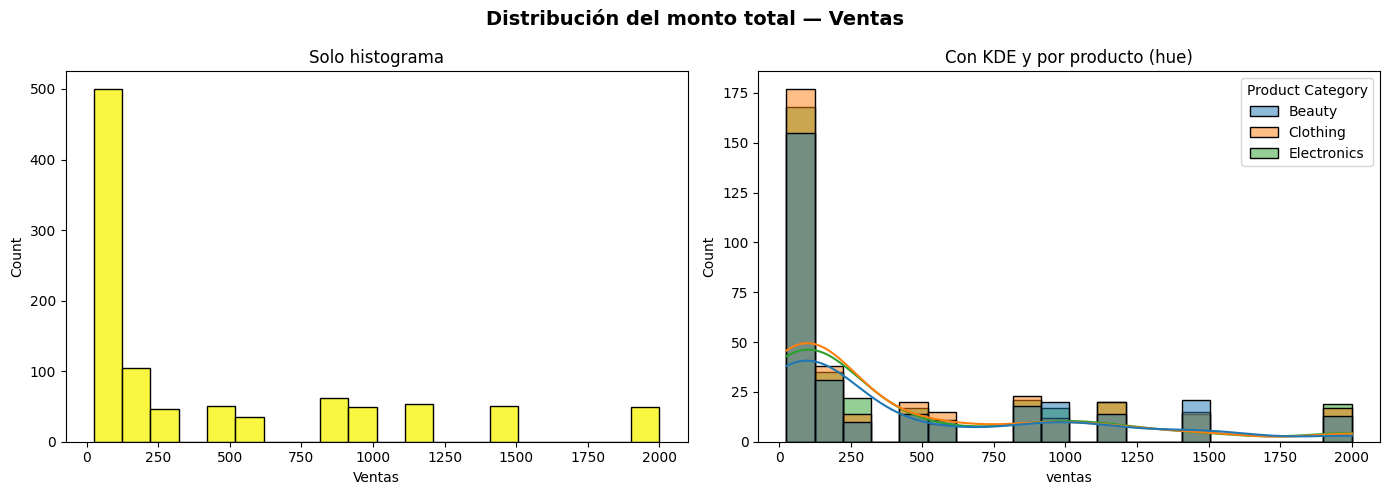

En el histograma combinado con KDE y separado por categoría de producto, se observa que la mayoría de
las ventas se concentran en el rango de $100 a $500, con una distribución ligeramente sesgada hacia la derecha.
Además, los productos Clothing parecen generar ventas más altas en comparación con las categorías Beauthy y Electronics,
lo que podría indicar una mayor demanda o un precio promedio más elevado para esos productos.


In [9]:
# Graficación de la distribución del monto total de ventas

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución del monto total — Ventas", fontsize=14, fontweight="bold")

# Izquierda: histograma simple
sns.histplot(data=df, x="Total Amount", bins=20,
             color="#F9F503", ax=axes[0])
axes[0].set_title("Solo histograma")
axes[0].set_xlabel("Ventas")

# Derecha: histograma + KDE + separado por especie
sns.histplot(data=df, x="Total Amount", hue="Product Category",
             kde=True, bins=20, alpha=0.5, ax=axes[1])
axes[1].set_title("Con KDE y por producto (hue)")
axes[1].set_xlabel("ventas")

plt.tight_layout()
plt.show()

print(f'En el histograma combinado con KDE y separado por categoría de producto, se observa que la mayoría de')
print(f'las ventas se concentran en el rango de $100 a $500, con una distribución ligeramente sesgada hacia la derecha.')
print(f'Además, los productos Clothing parecen generar ventas más altas en comparación con las categorías Beauthy y Electronics,')
print(f'lo que podría indicar una mayor demanda o un precio promedio más elevado para esos productos.')

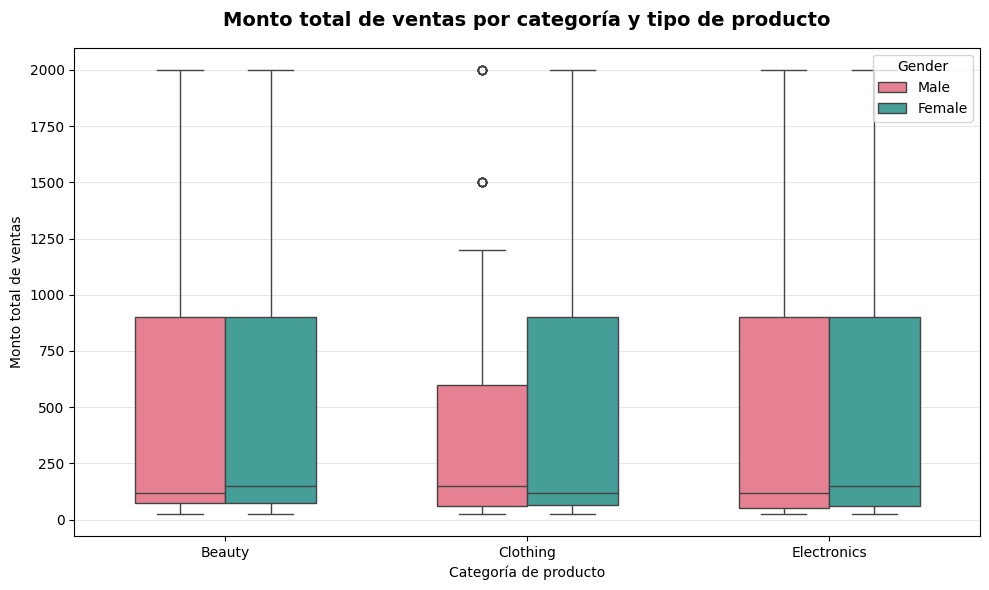

El boxplot revela que la categoría de producto Clothing para el género Femenino tiene una mediana de ventas
más alta en comparación con Beauthy y Electronics,


In [10]:
# Graficación de boxplot para monto total de ventas por categoría y género
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Product Category",
    y="Total Amount",
    hue="Gender",
    palette="husl",
    width=0.6,
    ax=ax
)

ax.set_title("Monto total de ventas por categoría y tipo de producto", fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Categoría de producto")
ax.set_ylabel("Monto total de ventas")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f'El boxplot revela que la categoría de producto Clothing para el género Femenino tiene una mediana de ventas')
print(f'más alta en comparación con Beauthy y Electronics,')

### c) Gráfico de líneas

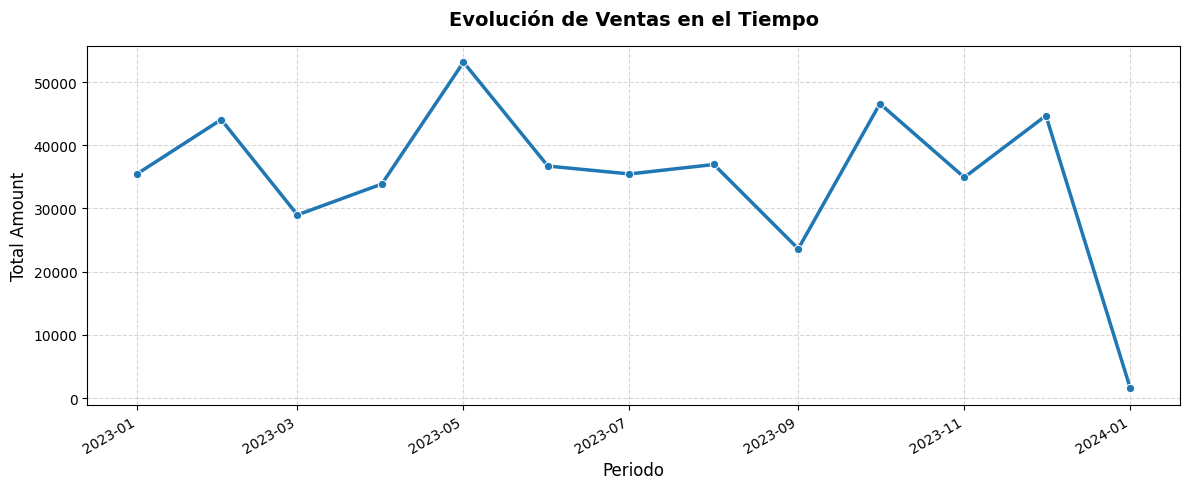

La gráfica de línea muestra una tendencia general de aumento en las ventas a lo largo del tiempo,
con algunos picos notables que podrían corresponder a eventos específicos o promociones.
Es importante investigar más a fondo las causas de estos picos para entender mejor el comportamiento del mercado
y optimizar futuras estrategias de ventas.


In [11]:
# Añadimos '-01' para simular el primer día de cada mes
df_agrupado['Date'] = pd.to_datetime(df_agrupado['Año'].astype(str) + '-' + df_agrupado['Mes'].astype(str) + '-01')

# ordenamos cronológicamente para que la línea no se cruce de forma errática
df_agrupado2 = df_agrupado.sort_values(by='Date')

# Configuración del estilo del gráfico
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_agrupado2, x='Date', y='Total Amount', marker='o',color='#1f77b4', linewidth=2.5)

# Personalización del diseño
plt.title('Evolución de Ventas en el Tiempo', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Periodo', fontsize=12)
plt.ylabel('Total Amount', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gcf().autofmt_xdate() 
plt.tight_layout()

plt.show()

print(f'La gráfica de línea muestra una tendencia general de aumento en las ventas a lo largo del tiempo,')
print(f'con algunos picos notables que podrían corresponder a eventos específicos o promociones.')
print(f'Es importante investigar más a fondo las causas de estos picos para entender mejor el comportamiento del mercado')
print(f'y optimizar futuras estrategias de ventas.')

### d) Gráfico de dispersión

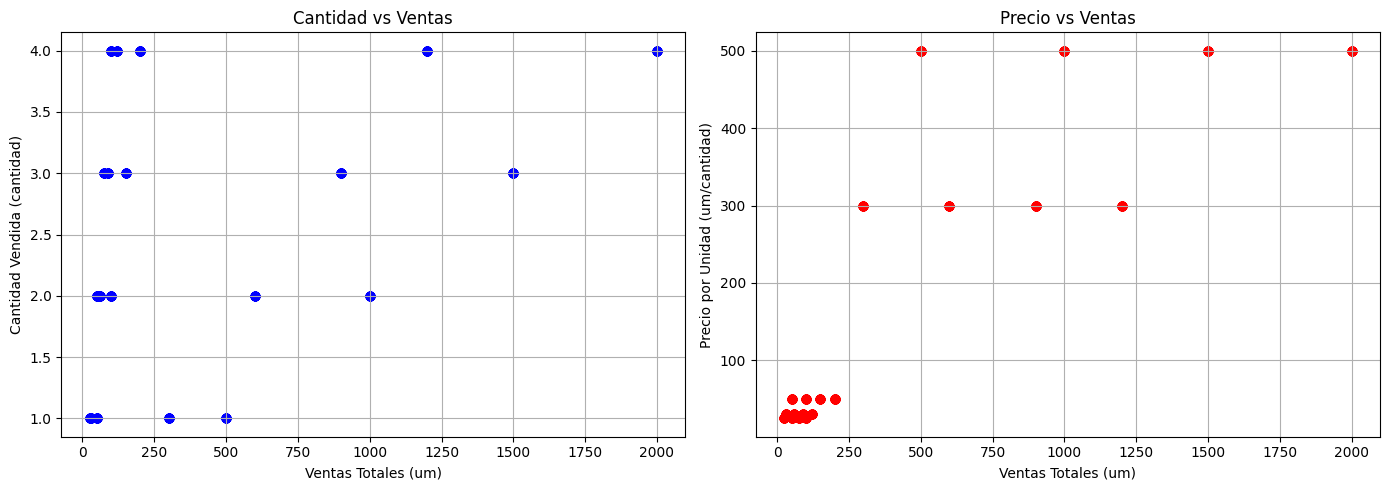

En el gráfico de Cantidad vs Ventas, se observa una tendencia positiva, indicando que a medida que aumentan las ventas totales,
también tiende a aumentar la cantidad vendida

En el gráfico de Precio vs Ventas, se aprecia una relación más dispersa, lo que podría indicar que el precio por unidad
no es el único factor determinante de las ventas totales,


In [12]:
# Crear la figura y el subplot de 1 fila x 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cantidad vs Ventas ---
axes[0].scatter(df['Total Amount'], df['Quantity'], color='blue', alpha=0.7)
axes[0].set_title('Cantidad vs Ventas')
axes[0].set_xlabel('Ventas Totales (um)')
axes[0].set_ylabel('Cantidad Vendida (cantidad)')
axes[0].grid(True)

# Precio vs Ventas ---
axes[1].scatter(df['Total Amount'], df['Price per Unit'], color='red', alpha=0.7)
axes[1].set_title('Precio vs Ventas')
axes[1].set_xlabel('Ventas Totales (um)')
axes[1].set_ylabel('Precio por Unidad (um/cantidad)')
axes[1].grid(True)

# Ajustar automáticamente el espacio entre los gráficos
plt.tight_layout()

# Mostrar la figura con ambos subplots
plt.show()

print(f'En el gráfico de Cantidad vs Ventas, se observa una tendencia positiva, indicando que a medida que aumentan las ventas totales,')
print(f'también tiende a aumentar la cantidad vendida')
print(f'\nEn el gráfico de Precio vs Ventas, se aprecia una relación más dispersa, lo que podría indicar que el precio por unidad')
print(f'no es el único factor determinante de las ventas totales,')

### e) Combinación histogramas y boxplots

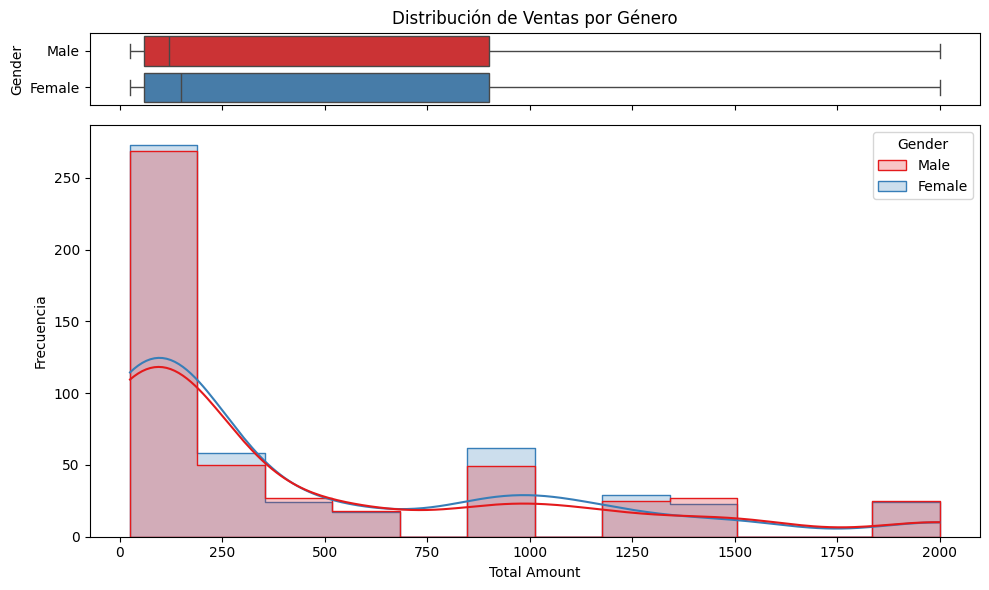

En el histograma combinado con KDE y separado por género, se observa que las ventas para ambos géneros se concentran
en un rango similar, aunque el género Femenino muestra una distribución ligeramente más amplia,
lo que podría indicar una mayor variabilidad en las ventas dentro de ese grupo.


In [13]:
# Configuración figura con subplots compartidos (Este código se mejoró con ayuda de google)
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))

# Dibujar el Boxplot (arriba)
sns.boxplot(data=df, x="Total Amount", y="Gender", hue="Gender", ax=ax_box, palette="Set1")
ax_box.set(xlabel='') # Eliminar etiqueta x del boxplot
ax_box.set_title('Distribución de Ventas por Género')

# Dibujar el Histograma (abajo)
sns.histplot(data=df, x="Total Amount", hue="Gender", element="step", ax=ax_hist, palette="Set1", kde=True)
ax_hist.set(ylabel='Frecuencia')


plt.tight_layout()
plt.show()

print(f'En el histograma combinado con KDE y separado por género, se observa que las ventas para ambos géneros se concentran')
print(f'en un rango similar, aunque el género Femenino muestra una distribución ligeramente más amplia,') 
print(f'lo que podría indicar una mayor variabilidad en las ventas dentro de ese grupo.')

## Conclusiones y comentarios

- En resumen, el análisis visual de los datos de ventas revela varias tendencias clave:
    - La mayoría de las ventas se concentran en el rango de $100 a $500, con una distribución ligeramente sesgada hacia la derecha.
    - Los productos Clothing parecen generar ventas más altas en comparación con las categorías Beauthy y Electronics,lo que podría indicar una mayor demanda o un precio promedio más elevado para esos productos.
    - La categoría de producto Clothing para el género Femenino tiene una mediana de ventas más alta en comparación con Beauthy y Electronics, lo que sugiere que las mujeres podrían estar comprando más productos de esa categoría o que los productos de Clothing para mujeres tienen un precio promedio más alto, lo que podría ser un área de oportunidad para enfocar futuras estrategias de marketing y ventas.
    - La evolución de las ventas a lo largo del tiempo muestra una tendencia general de aumento, con algunos picos notables que podrían corresponder a eventos específicos o promociones, lo que sugiere la importancia de investigar más a fondo las causas de estos picos para entender mejor el comportamiento del mercado y optimizar futuras estrategias de ventas.